# Nonadiabatic Dynamics with Shin-Metiu Hamiltonians


## Table of Content: <a name="TOC"></a>

1. [Generic setups](#1)   

2. [Define Shin-Metiu model parameters](#2)

3. [Plotting the PES](#3)

4. [Choose the initial conditions: Nuclear and electronic](#4)

5. [Running the simulation](#5)

6. [Plotting the dynamics results](#6)



## A. Learning objectives

- Define model and dynamics parameters
- Initialize nuclear and electronic degrees of freedom
- Run the Ehrenfest dynamics (with other TSH methods as options) in polaritonic basis
- Plot the resulting dynamics


## B. Use cases

- Shin-Metiu dyanmics


## C. Functions


- libra_py
  - models
    - Shin_Metiu
      - shin_metiu_dvr
        - [compute_model](#compute_model-1)
        - [dump_dvr_to_hdf5](#dump_dvr_to_hdf5-1)
  - dynamics
    - `tsh`
      - `compute`
        - [`generic_recipe`](#generic_recipe-1)
      - `plot`
        - [`plot_dynamics`](#plot_dynamics-1)     

## D. Classes and class members


## 1. Generic setups
<a name="1"></a>[Back to TOC](#TOC)

Here, we import all necessary libraries, set up some definitions (e.g. colors), and define the function that would be calling model Hamiltonians also defined within Libra package.

In [ ]:
#Importing Required Libraries
import math, h5py
import numpy as np
import warnings
from functools import reduce
import matplotlib.pyplot as plt   # plots

# Core simulation modules
from libra_py.models.Shin_Metiu.shin_metiu_dvr import compute_model,dump_dvr_to_hdf5
from liblibra_core import *
from libra_py import units
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot
from libra_py.dynamics.tsh.recipes import fssh_g_jt


# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red
colors.update({"12": "#FF4500"})  # orangered
colors.update({"13": "#B22222"})  # firebrick
colors.update({"14": "#DC143C"})  # crimson
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13","23", "14", "24"]

<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

## 2. Define Shin-Metiu model parameters
<a name="2"></a>[Back to TOC](#TOC)

We define all important parameters for the Shin-Metiu models.
There are two different types of Shin-Metiu model (called as SM1 and SM2 respectively):

For the SM1, the electronic–nuclear potential is written as:
\begin{equation}
\hat{V}_{\mathrm{en}}=\sum_{\sigma= \pm 1}\left(\frac{1}{\left|R+\frac{\sigma L}{2}\right|}-\frac{\operatorname{erf}\left(\frac{\left|r+\frac{\sigma L}{2}\right|}{R_{\mathrm{c}}}\right)}{\left|r+\frac{\sigma L}{2}\right|}\right)-\frac{\operatorname{erf}\left(\frac{|R-r|}{R_{\mathrm{c}}}\right)}{|R-r|}
\end{equation}
For the SM2, the electronic–nuclear potential is written as:
\begin{equation}
\hat{V}_{\mathrm{en}}=\sum_{\sigma= \pm 1}\left(\frac{1}{\left|R+\frac{\sigma L}{2}\right|}-\frac{\operatorname{erf}\left(\frac{\left|r+\frac{\sigma L}{2}\right|}{a_\sigma}\right)}{\left|r+\frac{\sigma L}{2}\right|}\right)-\frac{\operatorname{erf}\left(\frac{|R-r|}{a_f}\right)}{|R-r|}
\end{equation}
Here we define the default parameters based on J. Chem. Phys. 157, 104118 (2022) paper.

We note that SM models defined here are NOT the typical model Hamiltonians in diabatic representation. With the above potential functions,
one has to solve the "electronic SM Hamiltonian" first, e.g., using DVR, to obtain the adiabatic energy and NACs. This makes the interface
between SM models and Libra more like the interface to an electronic structure program. To guarantee the continuity of NACs, we choose to
save the adiabatic PESs and NACs with simple phase corrections to a HDF5 file. The compute_model function will read information in the HDF5
file and return the phase-corrected Hamiltonians. This step also eliminate the need to recalculate SM DVR in each dynamics step.

In [ ]:
# ===============================================================
# Shin-Metiu Model Parameters and R-grid Setup
#
# This block defines the parameters for a 1D Shin-Metiu model
# simulation using the DVR (Discrete Variable Representation) method.
# It includes:
# - Grid parameters for electron coordinate (r)
# - Number of electronic states to retain
# - Model type (1 or 2)
# - Model-specific softening parameters (for model 1)
# - Range of nuclear positions (R) to sample
# ===============================================================

params = {
    "N": 300,          # Number of DVR grid points for the electron coordinate (r)
    "r_min": -22.0,    # Minimum value of r (left boundary of grid)
    "r_max": 22.0,     # Maximum value of r (right boundary of grid)
    "nstates": 2,      # Number of adiabatic states to compute/retain
    "model": 1,        # Model type (1 = smooth model 1, 2 = model 2)
}

# --- Model 1-specific softening parameters ---
params["L_sm1"] = 18.897     # Softening length (distance between fixed ions)
params["Rc_sm1"] = 2.8345    # Softening parameter (Gaussian width for smoothing Coulomb)

# --- Range of nuclear positions R to compute DVR at ---
# This defines the positions of the moving nucleus.
# A finer grid gives more resolution but increases computation cost.
# This is the grids for both PES plotting and the interpolation in dynamics.
R_values = np.linspace(-10, 10, 21)  # 21 equally spaced values between -10 and 10
results = [compute_model(R, params) for R in R_values]
dvr_file = "shin_metiu_dvr_data.h5"
dump_dvr_to_hdf5(R_values, results, dvr_file)

21 2


## 3. Plotting the PES
<a name="3"></a>[Back to TOC](#TOC)

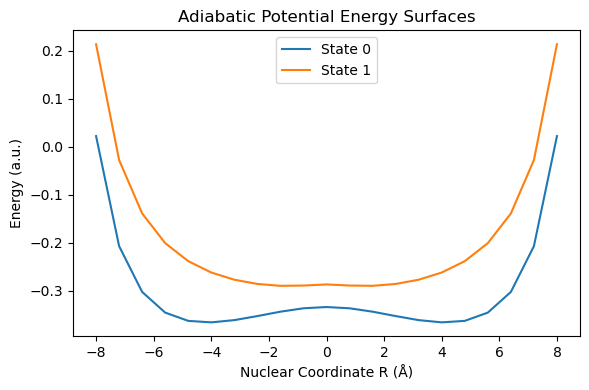

In [ ]:
# ===============================================================
# PLOTTING EXAMPLE
# ===============================================================
with h5py.File(dvr_file, 'r') as f:
    eigvals_info = f['eigvals'][:]
    nac_info = f['nac'][:]

plt.figure(figsize=(6,4))
for i in range(params["nstates"]):
    plt.plot(R_values, eigvals_info[:,i], label=f"State {i}")
plt.xlabel("Nuclear Coordinate R (Å)")
plt.ylabel("Energy (a.u.)")
plt.title("Adiabatic Potential Energy Surfaces")
plt.legend()
plt.tight_layout()
plt.show()

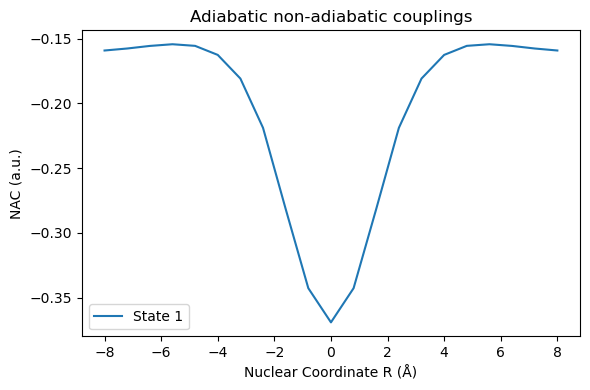

In [ ]:

plt.figure(figsize=(6,4))
plt.plot(R_values, nac_info[:,0,1], label=f"State {i}")
plt.xlabel("Nuclear Coordinate R (Å)")
plt.ylabel("NAC (a.u.)")
plt.title("Adiabatic non-adiabatic couplings")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Choose the initial conditions: Nuclear and Electronic
<a name="4"></a>[Back to TOC](#TOC)

In [ ]:
# Initialization type for nuclear DOFs:
# 0: fixed coords and momenta
# 1: fixed coords, sampled momenta
# 2: sampled coords, fixed momenta
# 3: both coords and momenta sampled
# Here the paramters are set according to the J. Chem. Phys. 157, 104118 (2022) paper
icond_nucl = 3

nucl_params = {
    "ndof": 1,
    "q": [-7],                       # Initial position
    "p": [20],                      # Initial momentum
    "mass": [1836.0],                 # Proton mass in a.u.
    "force_constant": [0.000382**2 * 1836.0],
    "init_type": icond_nucl
}

#Initial Conditions：Electronic DOFs
# Representation:
# 0: diabatic wavefunctions
# 1: adiabatic wavefunctions
rep = 1

nstates = params["nstates"]
n_init = 0
# Initial population vector (all zeros except chosen initial state)
istates = [0.0] * nstates
istates[n_init] = 1.0

elec_params = {
    "verbosity": 2,
    "init_dm_type": 0,
    "ndia": nstates,
    "nadi": nstates,
    "rep": rep,
    "init_type": 0,
    "istates": istates,
    "istate": n_init
}

dyn_general = { "nsteps":500, "ntraj":100, "nstates":params["nstates"],
                "dt":0.1*units.fs2au, "num_electronic_substeps":1, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.1, "which_adi_states":range(nstates), "which_dia_states":range(nstates),
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi", "Cdia", "Epot_ave", "Ekin_ave", "Etot_ave",
                "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia", "mash_pop_adi", "mash_pop_dia"],
                "prefix":"adiabatic_md", "prefix2":"adiabatic_md"
              }
params["dvr_file"] = dvr_file
fssh_g_jt.load(dyn_general)

# Change default settings to be compatible with adiabatic representation
dyn_general.update({"ham_update_method":2})  # recompute only adiabatic Hamiltonian; use with file-based or on-the-fly workflows
dyn_general.update( {"ham_transform_method":0 }) # don't do any transforms; usually for NBRA or on-the-fly workflows,
dyn_general.update({"electronic_integrator":5 })   # 2-points, Hvib, integration with the second-point correction of Hvib, with exp_
dyn_params = dict(dyn_general)

## 6. Running the Simulation
<a name="6"></a>[Back to TOC](#TOC)

Running dynamics

In [ ]:
# Create a random number generator for stochastic parts
rnd = Random()

params["model0"] = 1
# Run the Ehrenfest simulation
res = tsh_dynamics.generic_recipe(
    dyn_params,
    compute_model,
    params,
    elec_params,
    nucl_params,
    rnd
)

Active states (adiabatic)
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Initial adiabatic populations
[1.0, 0.0]
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
======= Initialization type is 0 ========
setting representation 1 coefficient C_0 to 1.0
==

## 5. Plotting the results
<a name="5"></a>[Back to TOC](#TOC)

Plotting the quantities

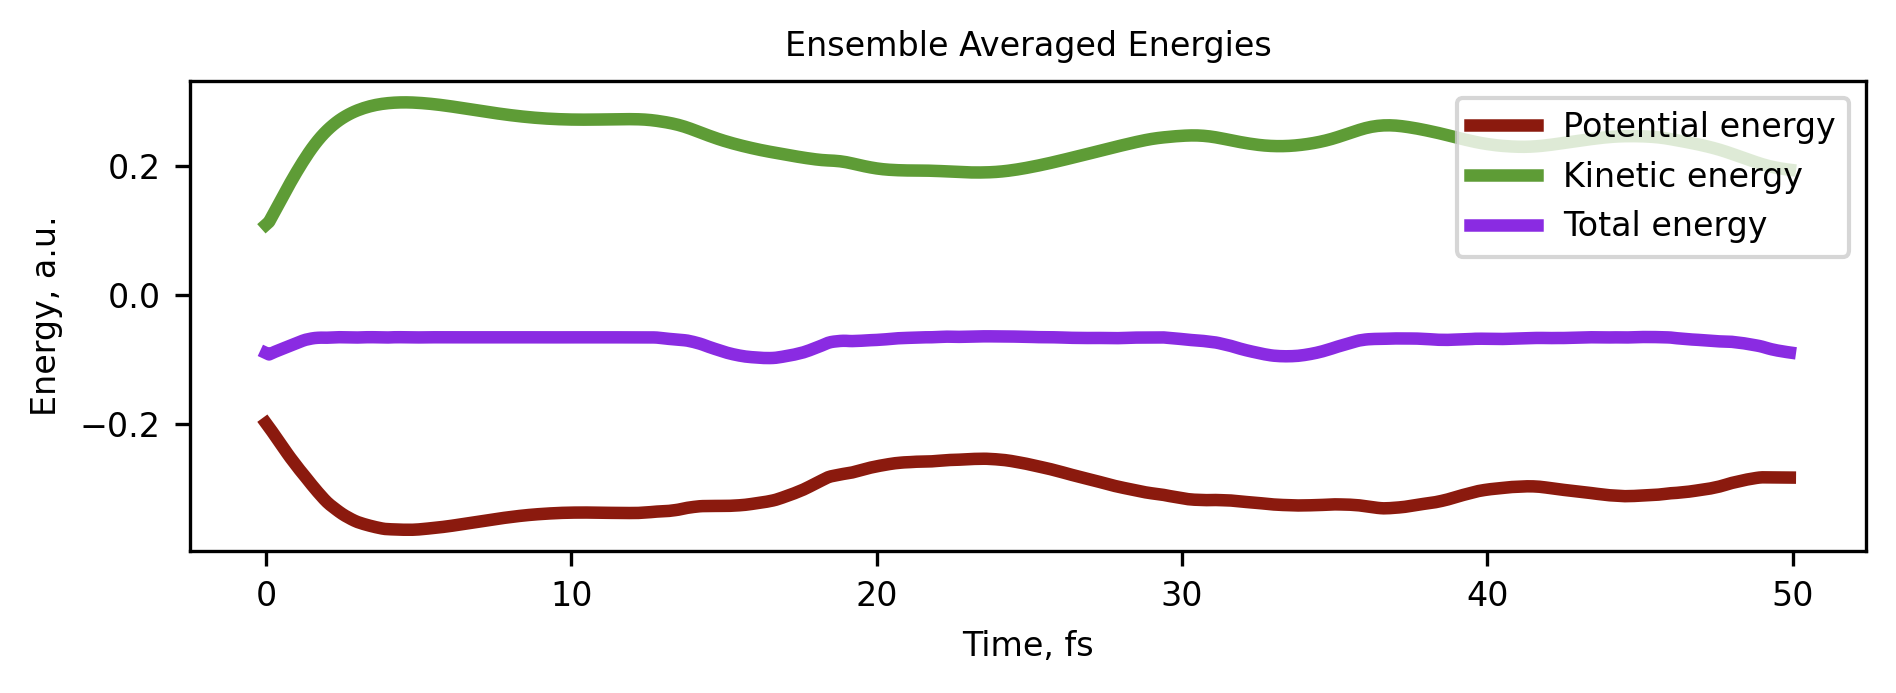

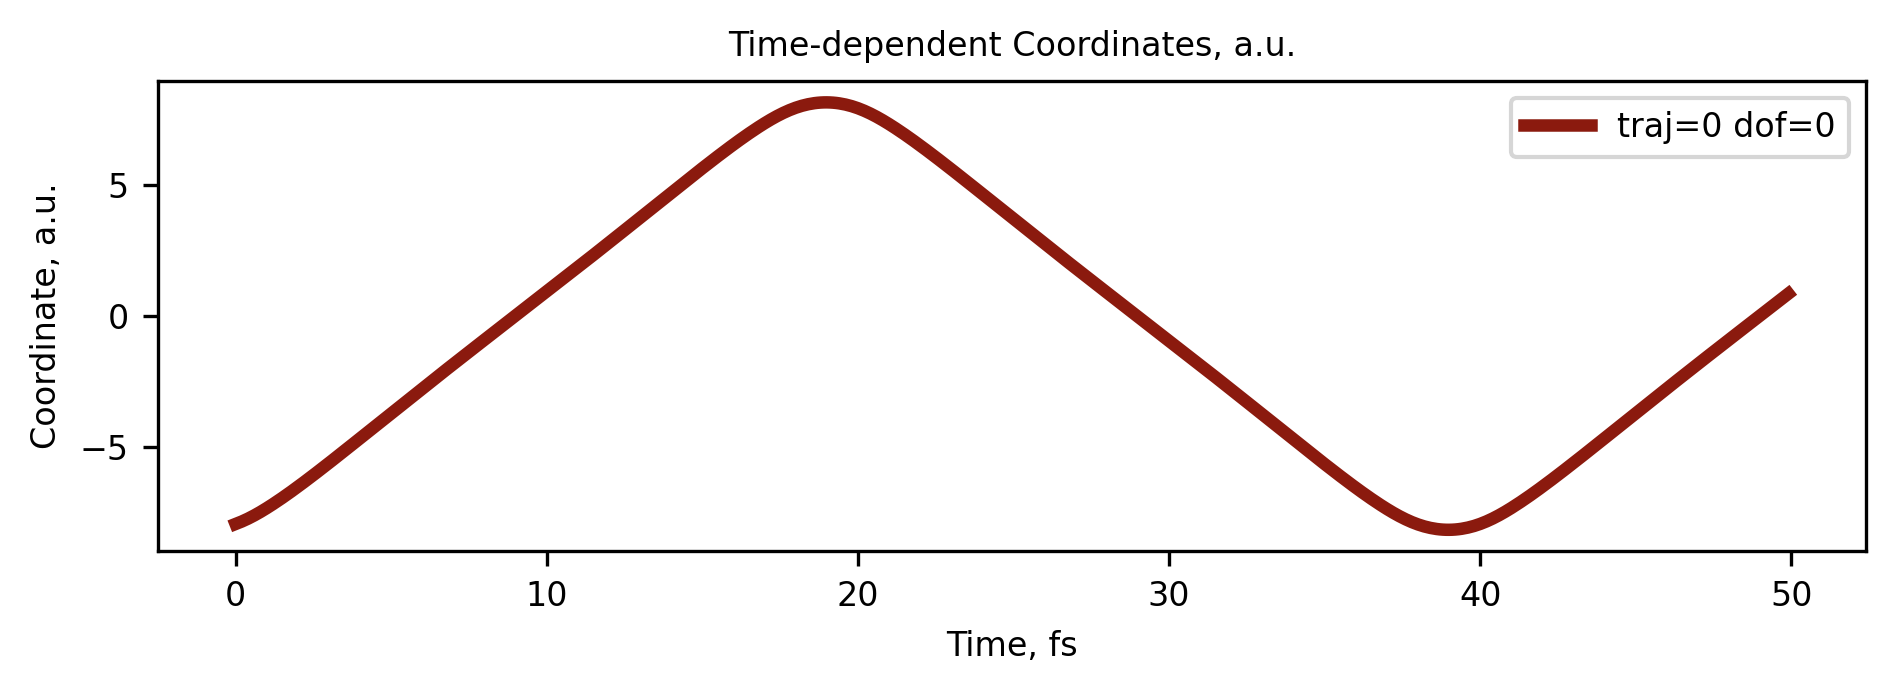

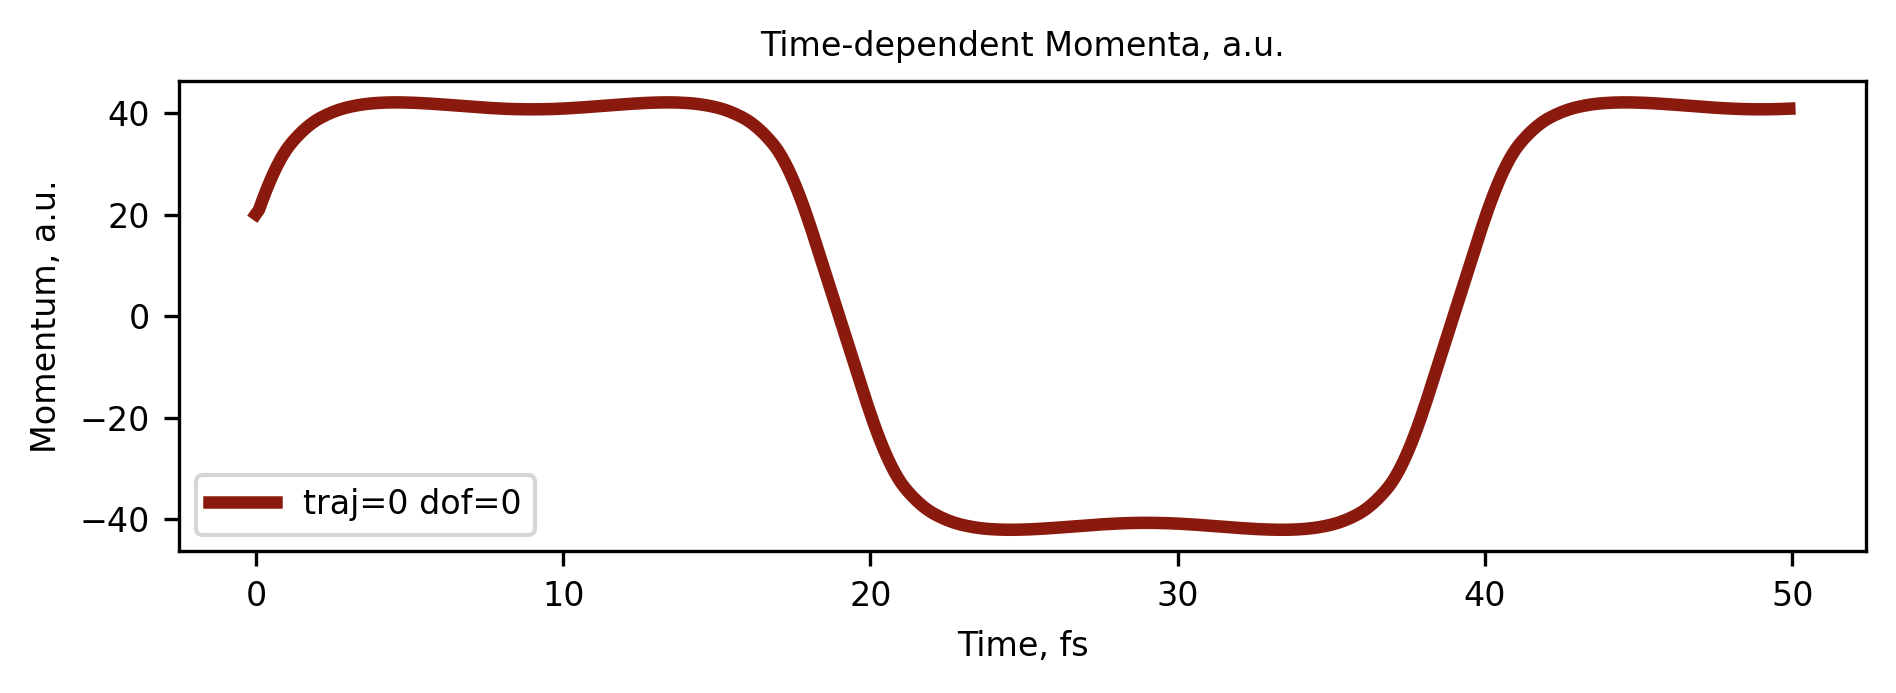

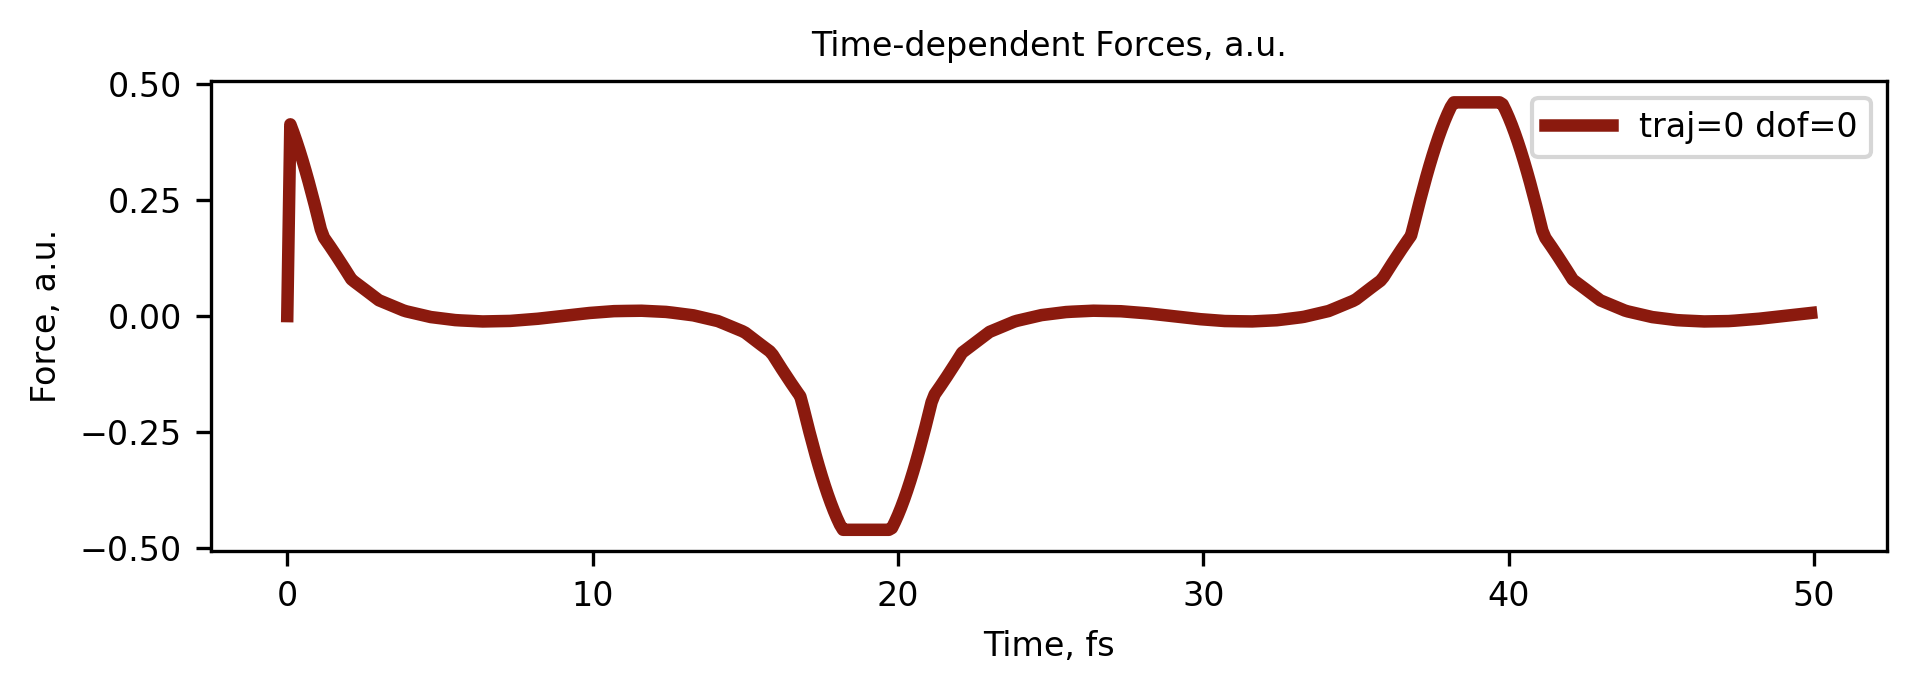

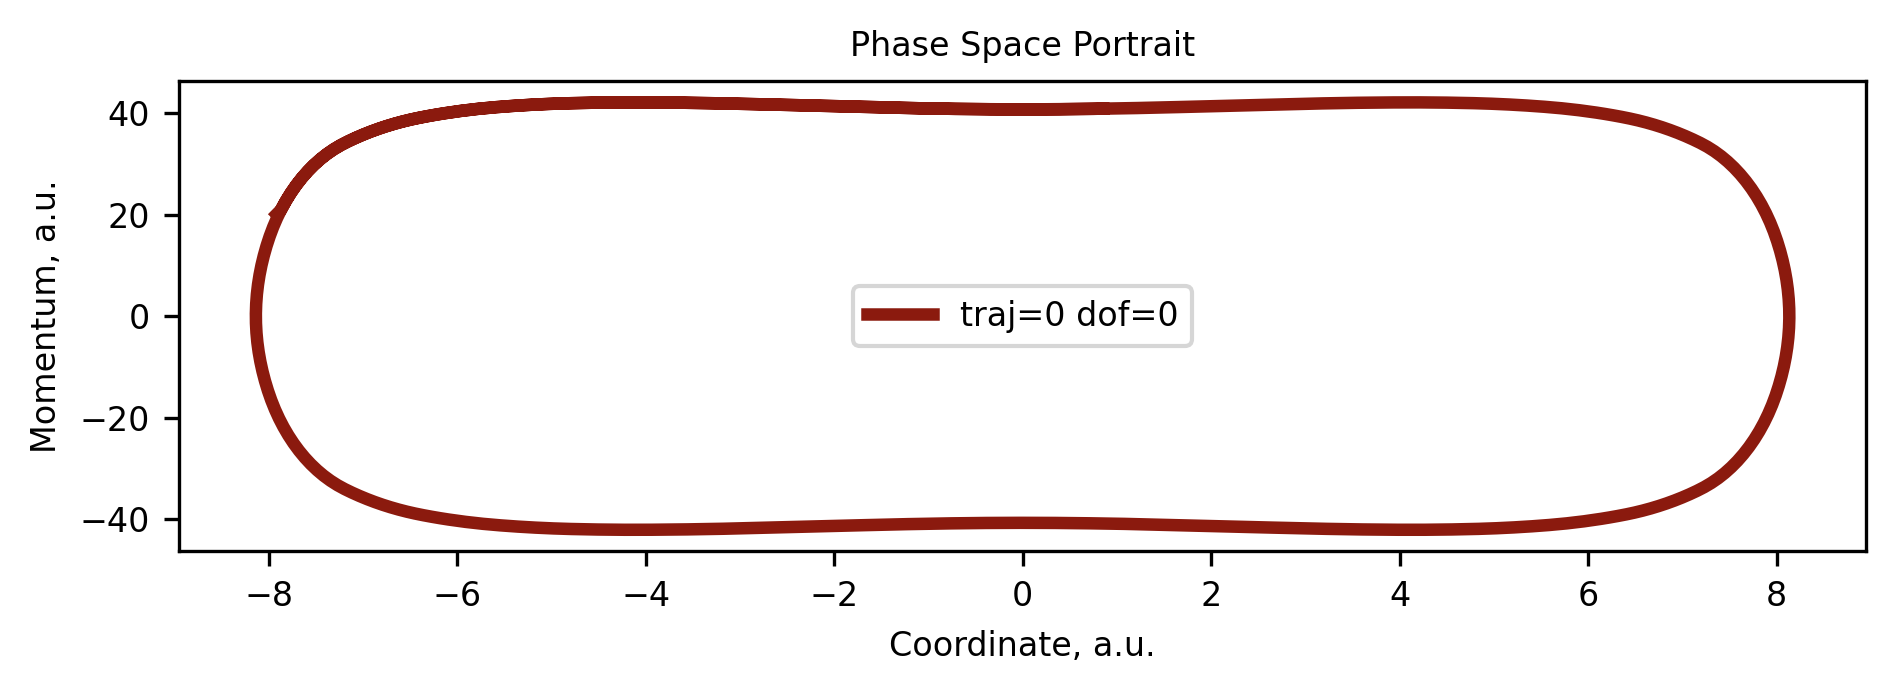

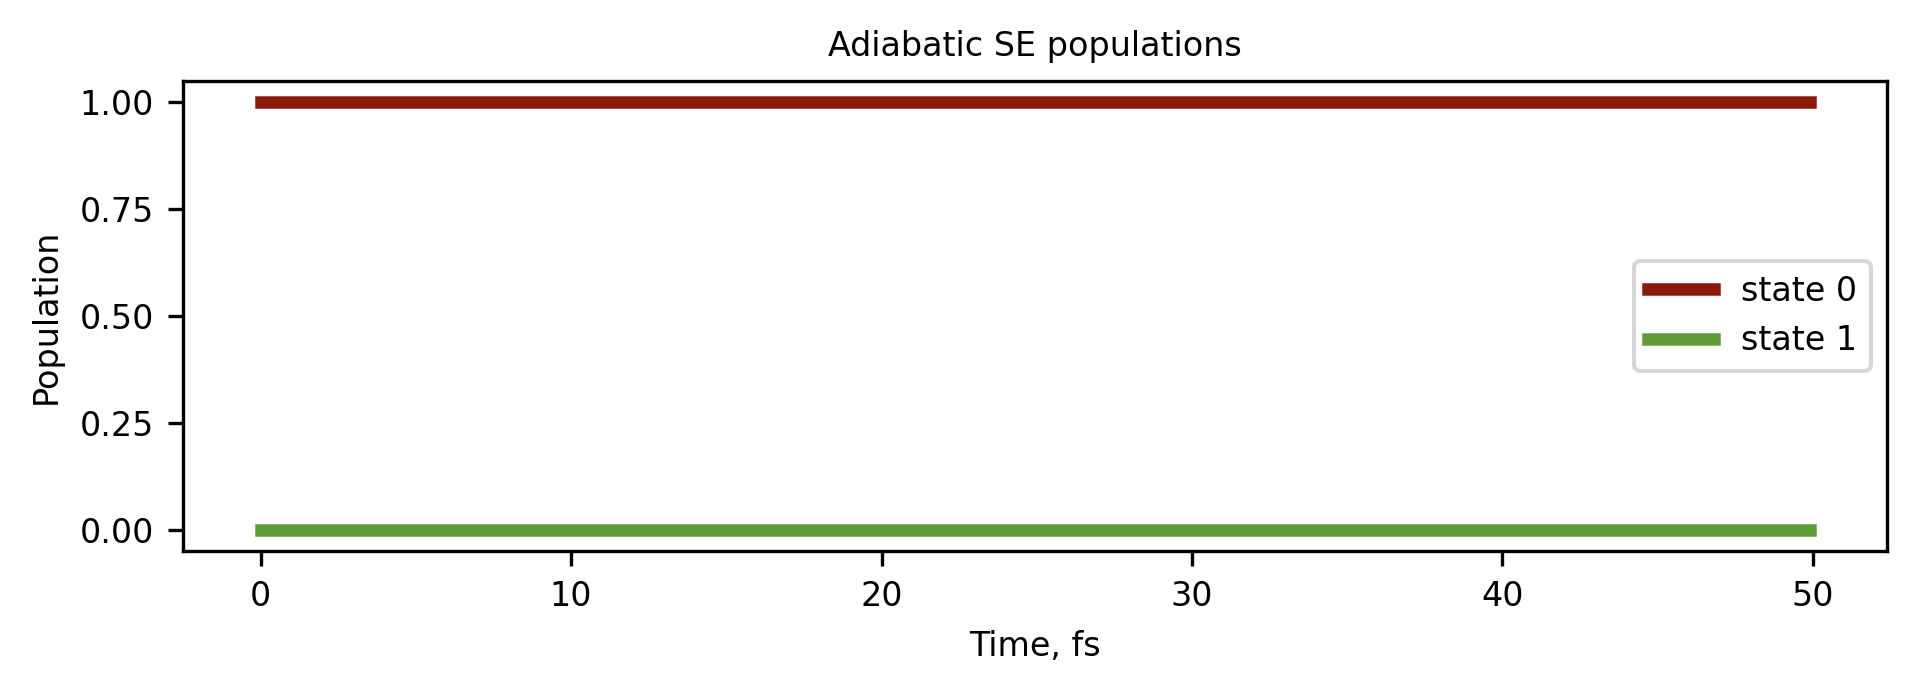

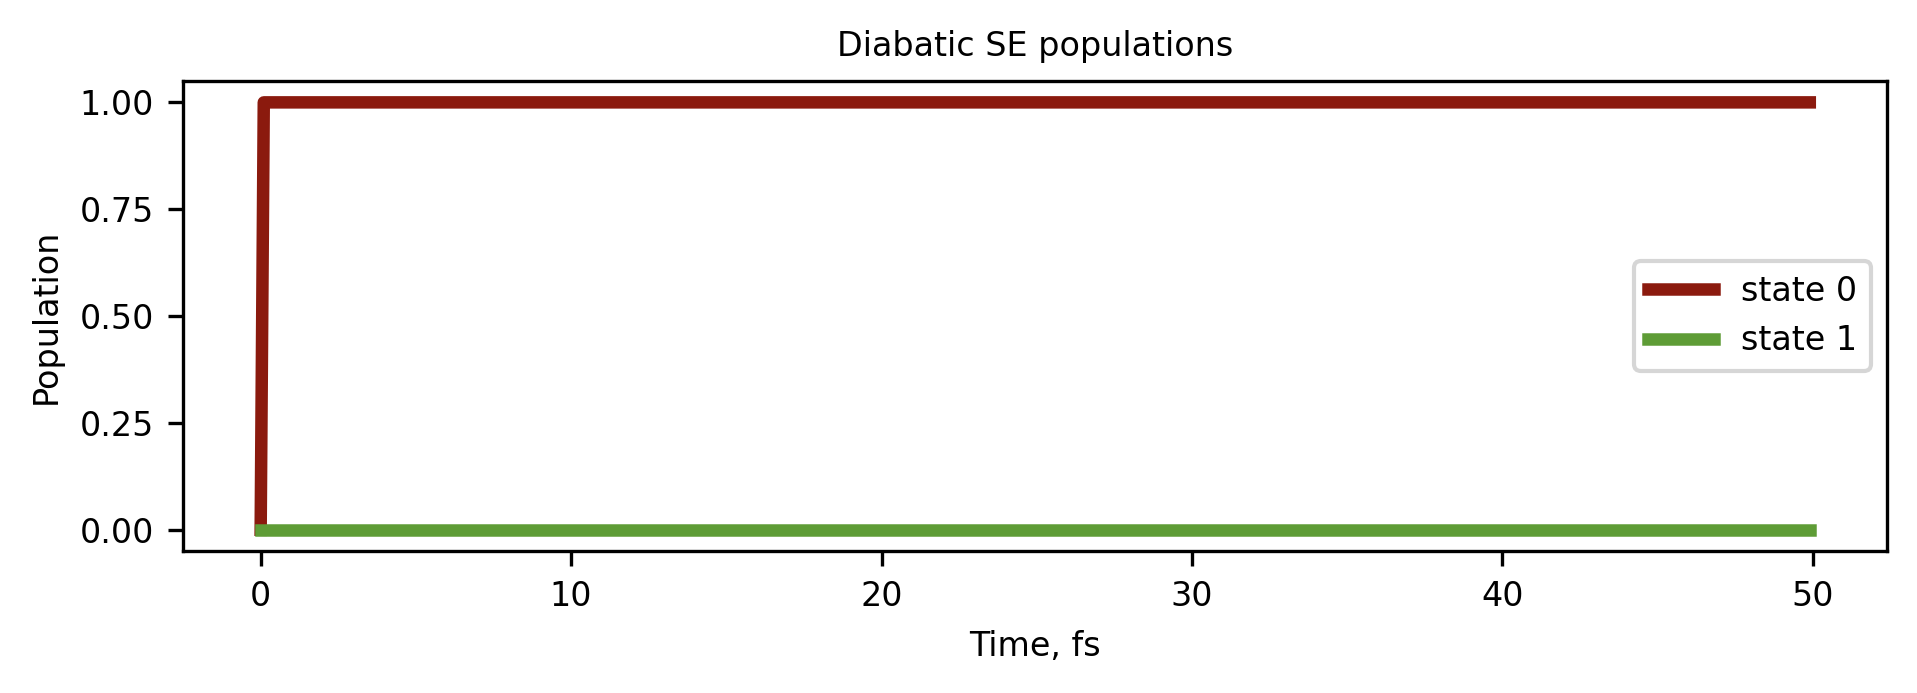

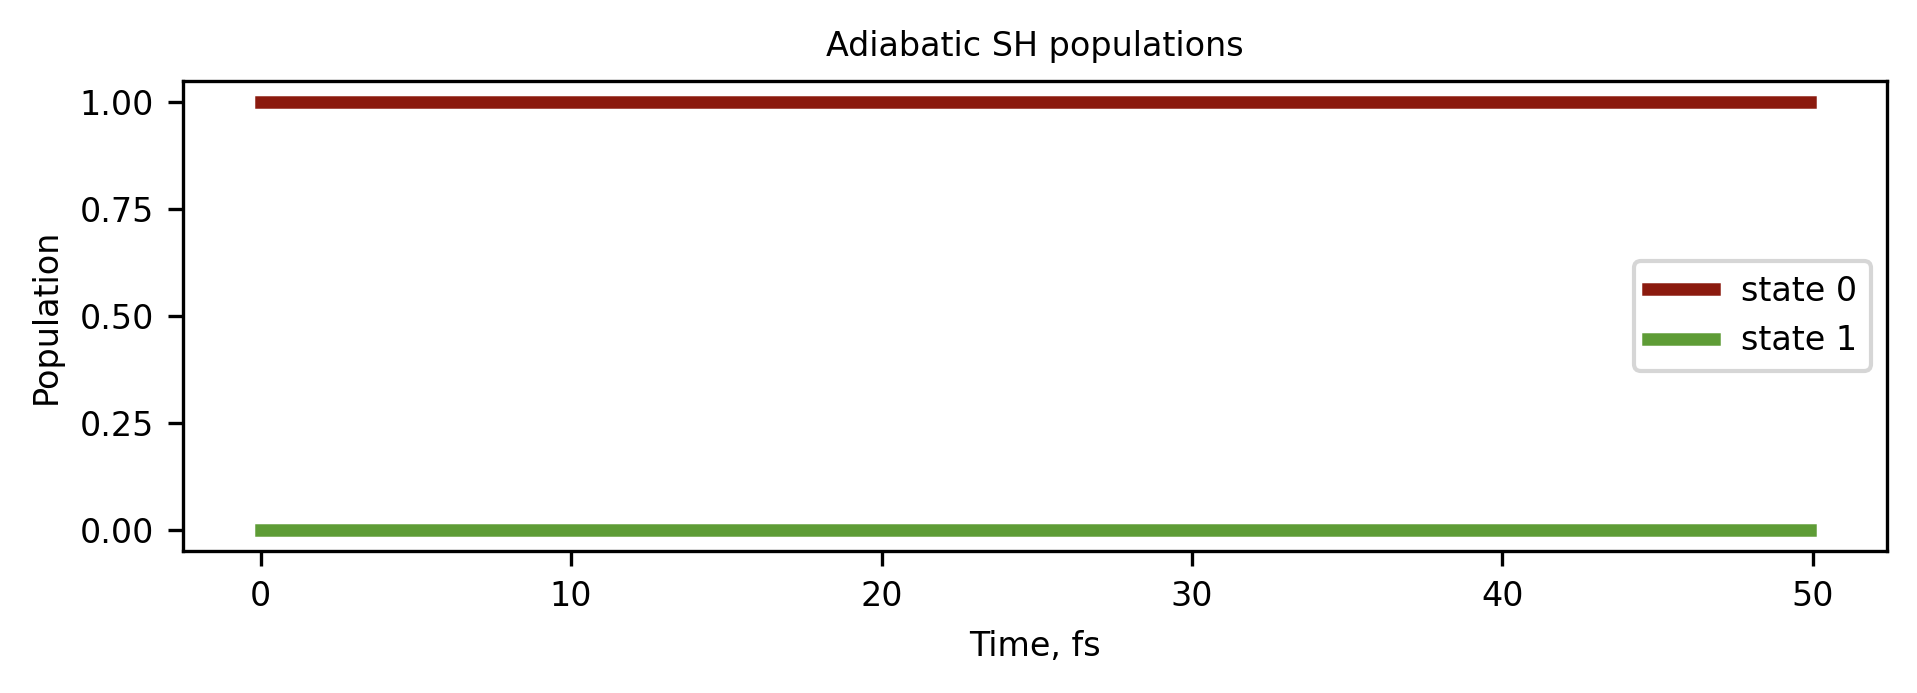

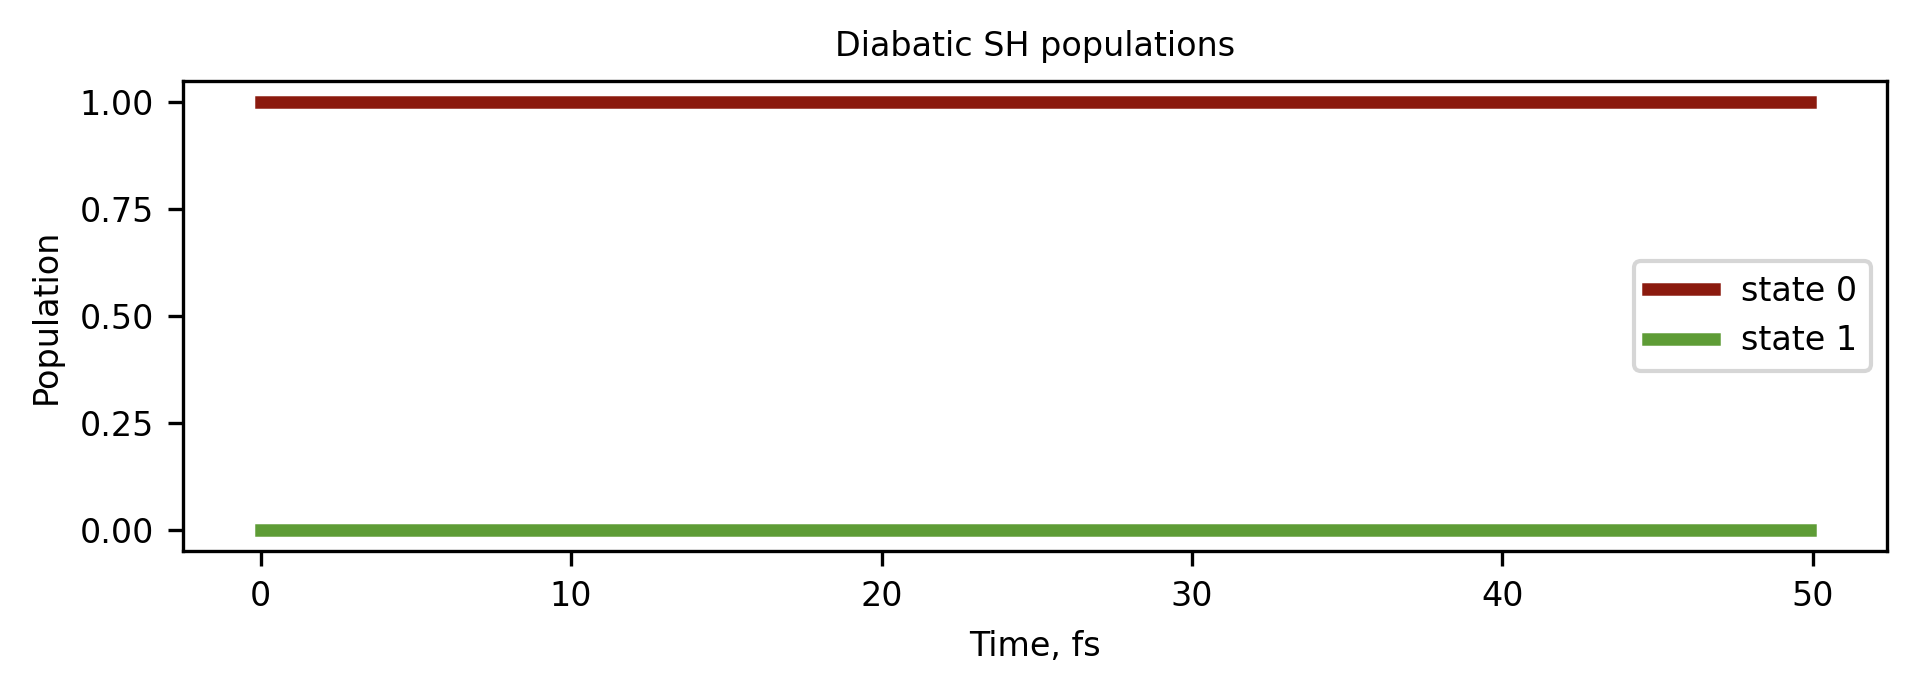

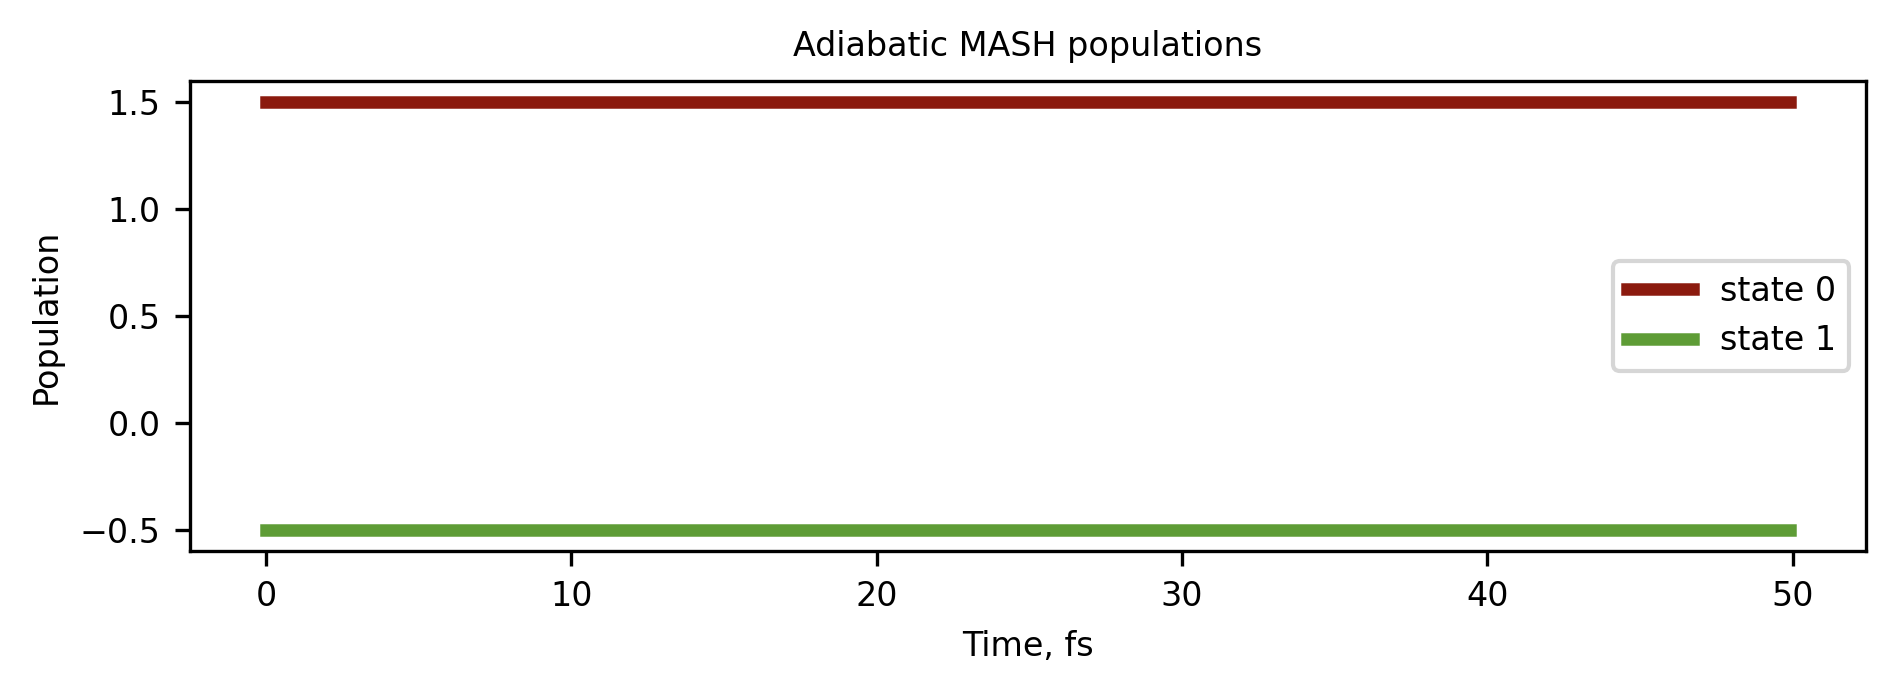

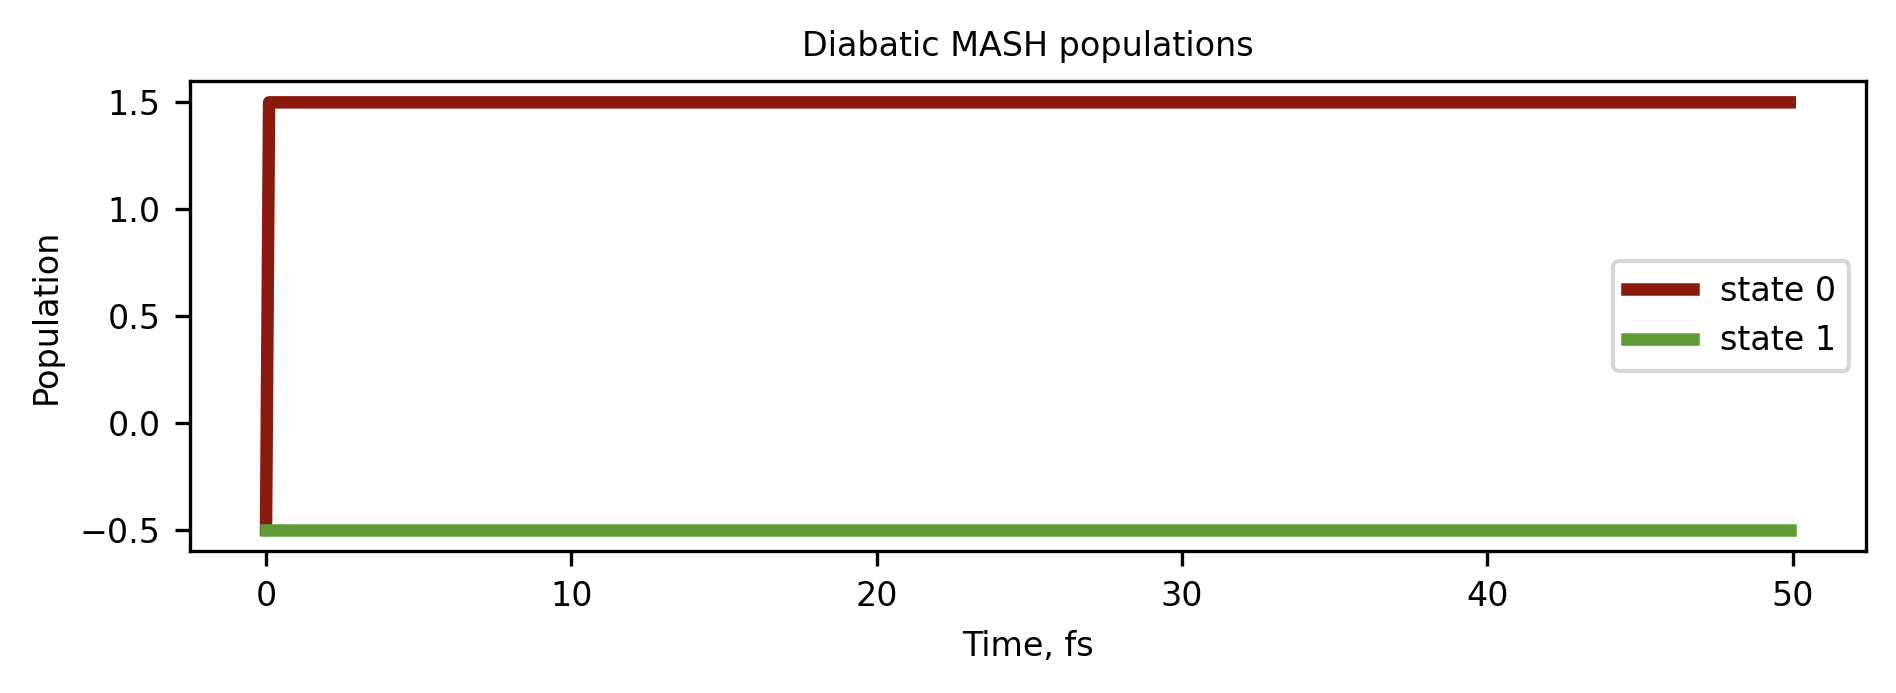

In [ ]:

plot_params = {
    "prefix": "adiabatic_md",
    "filename": "mem_data.hdf",
    "output_level": 3,
    "which_trajectories": [0],
    "which_dofs": [0],
    "which_adi_states": list(range(nstates)),
    "which_dia_states": list(range(nstates)),
    "frameon": True,
    "linewidth": 3,
    "dpi": 300,
    "axes_label_fontsize": (8,8),
    "legend_fontsize": 8,
    "axes_fontsize": (8,8),
    "title_fontsize": 8,
    "what_to_plot": [
        "coordinates", "momenta",  "forces", "energies", "phase_space",
        "se_pop_adi", "se_pop_dia", "sh_pop_adi", "sh_pop_dia",
        "mash_pop_adi", "mash_pop_dia"
    ],
    "which_energies": ["potential", "kinetic", "total"],
    "save_figures": 1,
    "do_show": 1
}

tsh_dynamics_plot.plot_dynamics(plot_params)